In [2]:
!pip install loompy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 kB 27.4 kB/s eta 0:00:00 0:00:01
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 60.4 kB/s eta 0:00:00 0:00:01m
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.3/53.3 kB 56.7 kB/s eta 0:00:00a 0:00:01
  Preparing metadata (setup.py) ... done
  Created wheel for loompy: filename=loompy-3.0.8-py3-none-any.whl size=54013 sha256=f37c9a05122ad702ed2774896b4694f0ddb5d920278113add926f14c712ea118
  Stored in directory: /root/.cache/pip/wheels/7a/b0/51/0054e104762c74124646fb54c3748d0fddd8efb7d5d5514464
  Created wheel for numpy-groupies: filename=numpy_groupies-0.9.22-py3-none-any.whl size=25846 sha256=6156323471e158f21f044c76d96cc8d27c2cec2c6ec9bb5b28d5b42e2b8b3546
  Stored in directory: /root/.cache/pip/wheels/2e/b9/5a/225e71b783e29f2098ba2dc8a5266f02b2d0d08f1890a28548
Successfully built loompy numpy-groupies


In [1]:
import pandas as pd
from samalg import SAM
import scanpy as sc
import statistics
import matplotlib.pyplot as plt
import seaborn as sns
import random
import pandas as pd
import matplotlib.colors
import scipy
import numpy as np
import sklearn.metrics as metrics
from scipy import sparse
import time
import loompy
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
import pickle

/scratch/miniconda/lib/python3.7/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
metadata = pd.read_csv('Allen_institute_labels_v2_classsubclasssupertype.csv')

In [3]:
with open('parent_dict.pkl', 'rb') as f:
    parent_dict = pickle.load(f)

In [5]:
dat = sc.read_h5ad('AIT17.0.rawcount.h5ad', backed = 'r')
metadata = pd.read_csv('Allen_institute_labels_v2_classsubclasssupertype.csv')
print('loaded data')

ncl = []
for item in dat.obs_names:
    split = item.split('-')
    ncl.append(split[0] + split[1])
dat.obs_names = ncl
print('renaming obs')

nlc_meta = []
for item in metadata.index:
    nlc_meta.append(metadata.loc[item, 'cell_barcode'] + metadata.loc[item, 'library_label'])
metadata.index = nlc_meta

loaded data
renaming obs


In [5]:
for item in metadata['supertype_id_label'].unique():
    if item not in parent_dict:
        parent_dict[item] = 'not hypo'
        print(item)

0280 STR D2 Gaba_7
0157 OB-in Frmd7 Gaba_8
0155 OB-in Frmd7 Gaba_6
0171 OB-STR-CTX Inh IMN_6
0172 OB-STR-CTX Inh IMN_7
1150 CBX MLI Megf11 Gaba_2
1016 VCO Mafa Meis2 Glut_4
0774 IC Tfap2d Maf Glut_5
0401 SI-MPO-LPO Lhx8 Gaba_6
1080 NLL-po Pax7 Gaba_1
1117 CU-ECU Pax2 Gly-Gaba_1
1078 PSV Pax2 Gly-Gaba_1
1079 PSV Pax2 Gly-Gaba_2
0682 RN Spp1 Glut_1
1025 HB Calcb Chol_1


In [6]:
len(metadata[metadata['subclass_id_label'] == '335 BAM NN'])

5626

In [6]:
subdat_dict = {}
level = 'subclass_id_label'
ct = metadata[level].unique()
for item in ct:
    subdat_dict[item] = list(metadata[metadata.loc[:,level] == item].index)

In [7]:
for item in subdat_dict.keys():
    if item not in parent_dict:
        parent_dict[item] = 'not hypo'

In [8]:
fin_obs = set(dat.obs_names) & set(metadata.index)
metadata = metadata.loc[fin_obs, :]

In [9]:
metadata['subclass_id_label'].nunique()

334

In [13]:
'133 PVH-SO-PVa Otp Glut' in set(metadata['subclass_id_label'].unique())

True

In [6]:
rhy = metadata[metadata['region_of_interest_acronym'] == 'HY']

In [12]:
rhy

,Unnamed: 0,cell_label,cell_barcode,barcoded_cell_sample_label,library_label,feature_matrix_label,entity,brain_section_label,library_method,region_of_interest_acronym,donor_label,donor_genotype,donor_sex,dataset_label,x,y,cluster_alias,subclass_id_label,supertype_id_label,class_id_label
ATACCGATCGCAATTGL8TX_200827_01_G09,1988085,ATACCGATCGCAATTG-345_D05,ATACCGATCGCAATTG,345_D05,L8TX_200827_01_G09,WMB-10Xv3-HY,cell,NaN,10Xv3,HY,Snap25-IRES2-Cre;Ai14-539606,Snap25-IRES2-Cre/wt;Ai14(RCL-tdT)/wt,M,WMB-10Xv3,2.747507,22.219066,14956,318 Astro-NT NN,1160 Astro-NT NN_2,30 Astro-Epen
GACAGAGGTCGTCTTCL8TX_180504_01_F01,2409814,GACAGAGGTCGTCTTC-026_A01,GACAGAGGTCGTCTTC,026_A01,L8TX_180504_01_F01,WMB-10Xv2-HY,cell,NaN,10Xv2,HY,Snap25-IRES2-Cre;Ai14-385673,Snap25-IRES2-Cre/wt;Ai14(RCL-tdT)/wt,M,WMB-10Xv2,-1.241269,7.674977,1489,098 AHN-SBPV-PVHd Pdrm12 Gaba,0452 AHN-SBPV-PVHd Pdrm12 Gaba_7,12 HY GABA
TGAGGGACATTCTCCGL8TX_201016_01_B04,179768,TGAGGGACATTCTCCG-389_B01,TGAGGGACATTCTCCG,389_B01,L8TX_201016_01_B04,WMB-10Xv3-HY,cell,NaN,10Xv3,HY,Snap25-IRES2-Cre;Ai14-546892,Snap25-IRES2-Cre/wt;Ai14(RCL-tdT)/wt,M,WMB-10Xv3,2.471507,1.892762,1972,126 ARH-PVp Tbx3 Glut,0556 ARH-PVp Tbx3 Glut_3,14 HY Glut
GAACATCTCGTGGGAAL8TX_181126_01_C11,2459656,GAACATCTCGTGGGAA-068_A01,GAACATCTCGTGGGAA,068_A01,L8TX_181126_01_C11,WMB-10Xv2-HY,cell,NaN,10Xv2,HY,Snap25-IRES2-Cre;Ai14-425676,Snap25-IRES2-Cre/wt;Ai14(RCL-tdT)/wt,F,WMB-10Xv2,3.425432,1.709969,1918,124 MPN-MPO-PVpo Hmx2 Glut,0547 MPN-MPO-PVpo Hmx2 Glut_2,14 HY Glut
CGGGTCATCTGGGCCAL8TX_181031_01_A07,2490990,CGGGTCATCTGGGCCA-063_B01,CGGGTCATCTGGGCCA,063_B01,L8TX_181031_01_A07,WMB-10Xv2-HY,cell,NaN,10Xv2,HY,Snap25-IRES2-Cre;Ai14-421227,Snap25-IRES2-Cre/wt;Ai14(RCL-tdT)/wt,M,WMB-10Xv2,4.112563,3.331071,2110,123 DMH Nkx2-4 Glut,0545 DMH Nkx2-4 Glut_2,14 HY Glut
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CAGCGTGGTCCCTCATL8TX_201210_01_C04,1592128,CAGCGTGGTCCCTCAT-459_B01,CAGCGTGGTCCCTCAT,459_B01,L8TX_201210_01_C04,WMB-10Xv3-HY,cell,NaN,10Xv3,HY,Snap25-IRES2-Cre;Ai14-554814,Snap25-IRES2-Cre/wt;Ai14(RCL-tdT)/wt,M,WMB-10Xv3,-10.590725,11.396219,5231,327 Oligo NN,1184 MOL NN_4,31 OPC-Oligo
CTAGAGTTCATCACCCL8TX_180504_01_F01,2486851,CTAGAGTTCATCACCC-026_A01,CTAGAGTTCATCACCC,026_A01,L8TX_180504_01_F01,WMB-10Xv2-HY,cell,NaN,10Xv2,HY,Snap25-IRES2-Cre;Ai14-385673,Snap25-IRES2-Cre/wt;Ai14(RCL-tdT)/wt,M,WMB-10Xv2,5.217787,2.734586,2089,128 VMH Fezf1 Glut,0563 VMH Fezf1 Glut_1,14 HY Glut
GGGTGAACATGTGGTTL8TX_220407_01_E06,211212,GGGTGAACATGTGGTT-1183_A01,GGGTGAACATGTGGTT,1183_A01,L8TX_220407_01_E06,WMB-10Xv3-HY,cell,NaN,10Xv3,HY,Snap25-IRES2-Cre;Ai14-619870,Snap25-IRES2-Cre/wt;Ai14(RCL-tdT)/wt,F,WMB-10Xv3,3.039301,-2.373156,2194,136 PMv-TMv Pitx2 Glut,0607 PMv-TMv Pitx2 Glut_3,14 HY Glut
GGGAGATGTCGAATCTL8TX_181019_01_C06,3893880,GGGAGATGTCGAATCT-062_A01,GGGAGATGTCGAATCT,062_A01,L8TX_181019_01_C06,WMB-10Xv2-HY,cell,NaN,10Xv2,HY,Snap25-IRES2-Cre;Ai14-418113,Snap25-IRES2-Cre/wt;Ai14(RCL-tdT)/wt,M,WMB-10Xv2,7.299156,-5.207739,2822,144 MM Foxb1 Glut,0630 MM Foxb1 Glut_1,16 HY MM Glut


In [7]:
NN = [i for i in rhy['subclass_id_label'].unique() if i[-2:] == 'NN']
obs = [i for i in rhy.index if rhy.loc[i,'subclass_id_label'] in NN]
hy = rhy[rhy.index.isin(obs)]

In [8]:
vc = hy['subclass_id_label'].value_counts().reset_index()
vc.columns = ['cell_type', 'count']

In [10]:
vc

,cell_type,count
0,327 Oligo NN,36627
1,318 Astro-NT NN,20865
2,326 OPC NN,9805
3,333 Endo NN,4303
4,334 Microglia NN,2839
5,331 Peri NN,1540
6,322 Tanycyte NN,974
7,332 SMC NN,904
8,323 Ependymal NN,498
9,330 VLMC NN,423


In [11]:
vc.to_csv('Allen_Institute_Numcells_nonneural_RegionHY_04082026.csv')

In [6]:
level = 'subclass_id_label'
HYPO = [i for i in metadata[level].unique() if parent_dict[parent_dict[i]] == 'hypo']

In [20]:
names = []
num_cells = 250
subset = False
for item in subdat_dict.keys():
    if item in HYPO:
        if len(subdat_dict[item]) > num_cells and subset:
            rsd = list(random.sample(subdat_dict[item], num_cells))
        else:
            rsd = subdat_dict[item]
        names = names + list(set(rsd))
print(len(names))

86232


In [21]:
findat = dat[dat.obs_names.isin(names)]

In [22]:
findat.write_h5ad('Subclustering/Allen_dat_334_microglia.h5ad')

In [23]:
dat_two = sc.read_h5ad('Subclustering/Allen_dat_334_microglia.h5ad')

In [24]:
dat_two.obs = metadata.loc[dat_two.obs_names,:]

In [25]:
dat_two.write_h5ad('Subclustering/Allen_dat_334_microglia.h5ad')

In [26]:
dat_two.raw = dat_two

In [50]:
dat_two.obs['Subclass'] = [i.replace(' ','_') for i in dat_two.obs['subclass_id_label']]

In [27]:
for item in dat_two.X[1,:]:
    print(item)

  (0, 63)	1.0
  (0, 126)	1.0
  (0, 156)	1.0
  (0, 168)	1.0
  (0, 219)	1.0
  (0, 238)	1.0
  (0, 272)	1.0
  (0, 300)	1.0
  (0, 413)	1.0
  (0, 443)	1.0
  (0, 485)	1.0
  (0, 493)	1.0
  (0, 539)	1.0
  (0, 620)	1.0
  (0, 626)	1.0
  (0, 661)	1.0
  (0, 683)	1.0
  (0, 727)	1.0
  (0, 751)	1.0
  (0, 758)	1.0
  (0, 824)	3.0
  (0, 835)	1.0
  (0, 844)	1.0
  (0, 967)	1.0
  (0, 1021)	1.0
  :	:
  (0, 29838)	1.0
  (0, 29874)	1.0
  (0, 29877)	1.0
  (0, 29982)	1.0
  (0, 30033)	1.0
  (0, 30216)	1.0
  (0, 30332)	1.0
  (0, 30522)	1.0
  (0, 30734)	1.0
  (0, 30877)	1.0
  (0, 30878)	1.0
  (0, 30903)	1.0
  (0, 30967)	1.0
  (0, 31040)	2.0
  (0, 31342)	1.0
  (0, 31450)	3.0
  (0, 31476)	1.0
  (0, 32195)	4.0
  (0, 32196)	2.0
  (0, 32197)	9.0
  (0, 32198)	4.0
  (0, 32200)	14.0
  (0, 32201)	9.0
  (0, 32205)	1.0
  (0, 32207)	7.0


In [28]:
dat_two

AnnData object with n_obs × n_vars = 86232 × 32285
    obs: 'Unnamed: 0', 'cell_label', 'cell_barcode', 'barcoded_cell_sample_label', 'library_label', 'feature_matrix_label', 'entity', 'brain_section_label', 'library_method', 'region_of_interest_acronym', 'donor_label', 'donor_genotype', 'donor_sex', 'dataset_label', 'x', 'y', 'cluster_alias', 'subclass_id_label', 'supertype_id_label', 'class_id_label'

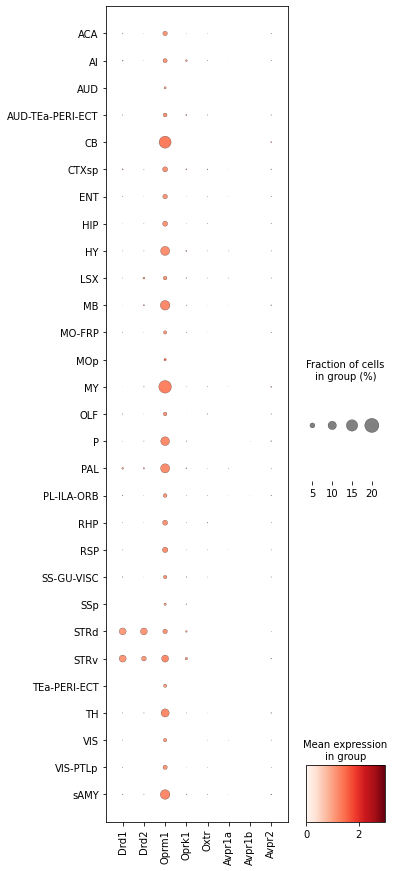

In [33]:
plt.rcParams["font.size"] = 12
plt.rcParams['figure.facecolor'] = 'white'
dp = sc.pl.dotplot(dat_two,
['Drd1','Drd2','Oprm1','Oprk1','Oxtr','Avpr1a','Avpr1b','Avpr2'], groupby = 'region_of_interest_acronym',
                   figsize=(5,15),vmax = 3,
                   mean_only_expressed = True,
                   return_fig = True)
dp.style(dot_max = .2,dot_min = 0,cmap = 'Reds')
#dp.savefig('Figures/Figures_10032025/Mouse_Celegans_hlh_genes_subclass_wholebrain.png',bbox_inches='tight', dpi = 300)
dp.show()

In [34]:
sam=SAM(dat_two)
sam.preprocess_data()
sam.run() #run with default parameters

RUNNING SAM
Iteration: 0, Convergence: 1.0
Iteration: 1, Convergence: 0.8399831590195489
Iteration: 2, Convergence: 0.017447036045702975
Computing the UMAP embedding...
Elapsed time: 489.98398518562317 seconds


In [54]:
sam.save_anndata('Active_SAM_joined/SAM_Allen_Institute_nonneural_2000_04072026.h5ad')